# STONE Slice-wise Analysis

This notebook extends the STONE analysis beyond the experiment-level curves shown at the bottom of `report_plots.ipynb`.

Instead of using only run-summary averages, it recomputes **slice-wise foreground and class-wise Dice** on the STONE test set for a representative subset of the `exp85_stone_l1` checkpoints.

## Scope

- experiment family: `exp85_stone_l1`
- pruning method: **uniform `l1` pruning**
- dataset: **`Dataset100_STONE_small`** by default, to stay aligned with the STONE pruning experiment configs
- comparison modes:
  - baseline
  - direct pruned models
  - retrained pruned models

## Important note about metadata

The `exp85_stone_l1` baseline metadata appears inconsistent and points back to ACDC paths. Because of that, this notebook:

- uses the `exp67_uniform_l1_acdc` baseline checkpoint explicitly for the baseline model
- uses the `exp85_stone_l1` pruned and retrained checkpoints for the pruning runs
- evaluates all selected checkpoints directly on STONE, rather than trusting the saved run-summary numbers alone


In [6]:
from __future__ import annotations

import json
import re
import sys
import warnings
from functools import lru_cache
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd
import torch
import torchvision.transforms.functional as TF
import yaml
from IPython.display import display
from matplotlib import pyplot as plt

REPO_ROOT = Path('/mnt/hdd/ttoxopeus/basic_UNet')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.models.unet import UNet
from src.pruning.rebuild import load_full_pruned_model

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RESULTS_ROOT = REPO_ROOT / 'results' / 'UNet_ACDC'
OUTPUT_ROOT = REPO_ROOT / 'results' / 'stone_slice_analysis'
CACHE_DIR = OUTPUT_ROOT / 'cache'
FIG_DIR = OUTPUT_ROOT / 'figures'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Device:', DEVICE)


Device: cuda


## Configuration

The configuration below keeps the notebook explicit and makes the selected checkpoints easy to inspect or change.


In [7]:
STONE_CFG = {
    'dataset_name': 'STONE_small',
    'images_ts': Path('/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset100_STONE_small/imagesTs'),
    'labels_ts': Path('/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset100_STONE_small/labelsTs'),
    'slice_axis': 2,
    'target_size': (256, 256),
    'num_classes': 4,
}

BASELINE_CFG = {
    'name': 'baseline',
    'display_name': 'Baseline',
    'mode': 'baseline',
    'config_path': RESULTS_ROOT / 'exp67_uniform_l1_acdc' / 'baseline' / 'config.yaml',
    'checkpoint_path': RESULTS_ROOT / 'exp67_uniform_l1_acdc' / 'baseline' / 'training' / 'final_model.pth',
    'params_m': 43.88634,
}

STONE_EXPERIMENT = RESULTS_ROOT / 'exp85_stone_l1'
SUMMARY_BASELINE_PARAMS_M = BASELINE_CFG['params_m']

CLASS_INFO = [
    ('RV', 1, '#F58518'),
    ('MYO', 2, '#54A24B'),
    ('LV', 3, '#4C78A8'),
]

# If None, the notebook auto-selects a small representative subset of runs.
MANUAL_RUN_NAMES = None


## Reused experiment-summary logic

`report_plots.ipynb` loads STONE runs from experiment summaries. This notebook reuses that discovery idea to identify candidate checkpoints, but then recomputes slice-wise metrics directly.


In [8]:
def read_json(path: Path) -> dict | None:
    if not path.exists():
        return None
    return json.loads(path.read_text())


def extract_pruning_ratio(run_name: str) -> float:
    if run_name == 'baseline':
        return 0.0
    vals = [int(x) for x in re.findall(r'\d+', run_name)]
    if not vals:
        return float('nan')
    return max(vals) / 100.0


def summarize_stone_runs() -> pd.DataFrame:
    rows = []
    for run_dir in sorted((STONE_EXPERIMENT / 'pruned').glob('l1_norm_*')):
        if not run_dir.is_dir():
            continue

        pruned_summary = read_json(run_dir / 'pruned_evaluation' / 'run_summary.json')
        retrained_summary = read_json(run_dir / 'retrained_pruned_evaluation' / 'run_summary.json')
        meta_path = run_dir / 'pruned_model' / 'pruned_model_meta.json'

        for mode, summary in [('pruned', pruned_summary), ('retrained', retrained_summary)]:
            if summary is None:
                continue
            eval_obj = summary.get('eval', {}) or {}
            fg = eval_obj.get('foreground', {}) or {}
            profile = summary.get('profile', {}) or {}
            ckpt_path = eval_obj.get('checkpoint')
            rows.append({
                'run_name': run_dir.name,
                'display_name': run_dir.name.replace('l1_norm_', 'ratio='),
                'mode': mode,
                'pruning_ratio': extract_pruning_ratio(run_dir.name),
                'params_m': profile.get('params_m'),
                'model_size_pct': 100.0 * float(profile.get('params_m')) / SUMMARY_BASELINE_PARAMS_M if profile.get('params_m') is not None else np.nan,
                'mean_dice_fg_summary': fg.get('dice_mean'),
                'std_dice_fg_summary': fg.get('dice_std'),
                'checkpoint_path': Path(ckpt_path) if ckpt_path else None,
                'meta_path': meta_path if meta_path.exists() else None,
                'run_dir': run_dir,
            })
    df = pd.DataFrame(rows)
    return df.sort_values(['mode', 'pruning_ratio']).reset_index(drop=True)


summary_df = summarize_stone_runs()
display(summary_df.head(10))
print('num pruned rows:', int((summary_df['mode'] == 'pruned').sum()))
print('num retrained rows:', int((summary_df['mode'] == 'retrained').sum()))


,run_name,display_name,mode,pruning_ratio,params_m,model_size_pct,mean_dice_fg_summary,std_dice_fg_summary,checkpoint_path,meta_path,run_dir
0,l1_norm_0_0_0_0_0_0_0_0_0_0_0,ratio=0_0_0_0_0_0_0_0_0_0_0,pruned,0.01,43.886340,100.000000,0.666951,0.295947,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...
1,l1_norm_5_5_5_5_5_5_5_5_5_5_5,ratio=5_5_5_5_5_5_5_5_5_5_5,pruned,0.05,39.698857,90.458345,0.650021,0.318434,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...
2,l1_norm_10_10_10_10_10_10_10_10_10_10_10,ratio=10_10_10_10_10_10_10_10_10_10_10,pruned,0.10,35.603687,81.127036,0.597846,0.344232,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...
3,l1_norm_15_15_15_15_15_15_15_15_15_15_15,ratio=15_15_15_15_15_15_15_15_15_15_15,pruned,0.15,31.808191,72.478569,0.453801,0.333436,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...
4,l1_norm_20_20_20_20_20_20_20_20_20_20_20,ratio=20_20_20_20_20_20_20_20_20_20_20,pruned,0.20,28.154221,64.152584,0.138675,0.177053,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...
5,l1_norm_25_25_25_25_25_25_25_25_25_25_25,ratio=25_25_25_25_25_25_25_25_25_25_25,pruned,0.25,24.689476,56.257770,0.019386,0.095084,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...
6,l1_norm_30_30_30_30_30_30_30_30_30_30_30,ratio=30_30_30_30_30_30_30_30_30_30_30,pruned,0.30,21.574889,49.160830,0.019636,0.095654,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...
7,l1_norm_35_35_35_35_35_35_35_35_35_35_35,ratio=35_35_35_35_35_35_35_35_35_35_35,pruned,0.35,18.585223,42.348537,0.019636,0.095654,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...
8,l1_norm_40_40_40_40_40_40_40_40_40_40_40,ratio=40_40_40_40_40_40_40_40_40_40_40,pruned,0.40,15.872655,36.167644,0.019636,0.095654,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...
9,l1_norm_45_45_45_45_45_45_45_45_45_45_45,ratio=45_45_45_45_45_45_45_45_45_45_45,pruned,0.45,13.324189,30.360675,0.019636,0.095654,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...,/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACD...


num pruned rows: 21
num retrained rows: 21


## Select representative checkpoints

To keep the slice-wise analysis readable, the notebook selects a compact subset automatically:

- baseline
- one medium-compression direct-pruned run
- one high-compression direct-pruned run
- the best retrained run with at least 50% compression
- a high-compression retrained run close to a 2% loss regime
- the most extreme retrained compression run

You can override this by setting `MANUAL_RUN_NAMES` above.


In [9]:
TARGET_RETRAINED_RATIOS = (0.25, 0.50, 0.75)


def select_representative_runs(summary_df: pd.DataFrame) -> pd.DataFrame:
    rows = [{
        'run_name': 'baseline',
        'display_name': 'Baseline',
        'mode': 'baseline',
        'pruning_ratio': 0.0,
        'params_m': BASELINE_CFG['params_m'],
        'model_size_pct': 100.0,
        'mean_dice_fg_summary': np.nan,
        'std_dice_fg_summary': np.nan,
        'checkpoint_path': BASELINE_CFG['checkpoint_path'],
        'meta_path': None,
        'run_dir': BASELINE_CFG['config_path'].parents[1],
    }]

    retrained = summary_df[summary_df['mode'] == 'retrained'].dropna(subset=['pruning_ratio']).copy()
    seen = {'baseline'}
    for target in TARGET_RETRAINED_RATIOS:
        if retrained.empty:
            continue
        row = retrained.iloc[(retrained['pruning_ratio'] - target).abs().argmin()]
        if row['run_name'] in seen:
            continue
        seen.add(row['run_name'])
        row_dict = row.to_dict()
        row_dict['display_name'] = f"Retrained {int(round(float(row['pruning_ratio']) * 100))}%"
        rows.append(row_dict)

    selected = pd.DataFrame(rows)
    return selected.sort_values(['mode', 'pruning_ratio']).reset_index(drop=True)


selected_runs_df = select_representative_runs(summary_df)
display(selected_runs_df[['run_name', 'display_name', 'mode', 'pruning_ratio', 'model_size_pct', 'mean_dice_fg_summary']])


,run_name,display_name,mode,pruning_ratio,model_size_pct,mean_dice_fg_summary
0,baseline,Baseline,baseline,0.00,100.000000,NaN
1,l1_norm_25_25_25_25_25_25_25_25_25_25_25,Retrained 25%,retrained,0.25,56.257770,0.692165
2,l1_norm_50_50_50_50_50_50_50_50_50_50_50,Retrained 50%,retrained,0.50,25.010361,0.707740
3,l1_norm_75_75_75_75_75_75_75_75_75_75_75,Retrained 75%,retrained,0.75,6.257774,0.650945


## Dataset and model helpers


In [10]:
def collect_stone_pairs(images_ts: Path, labels_ts: Path) -> list[dict]:
    pairs = []
    for label_path in sorted(labels_ts.glob('*.nii.gz')):
        image_path = images_ts / label_path.name
        if not image_path.exists():
            warnings.warn(f'Missing image for {label_path.name}')
            continue
        stem = label_path.name.replace('.nii.gz', '')
        patient_id = stem.split('_')[0]
        sequence_id = stem.split('_')[1] if '_' in stem else '0'
        pairs.append({
            'case_id': stem,
            'patient_id': patient_id,
            'sequence_id': sequence_id,
            'image_path': image_path,
            'label_path': label_path,
        })
    return pairs


def preprocess_image_slice(img_np: np.ndarray, target_size=(256, 256), clip_bounds=None):
    if clip_bounds is None:
        lo, hi = np.percentile(img_np, 1), np.percentile(img_np, 99)
    else:
        lo, hi = clip_bounds
    img_np = np.clip(img_np, lo, hi)
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
    img_t = torch.from_numpy(img_np).float().unsqueeze(0)
    img_t = TF.resize(img_t, target_size, antialias=True)
    return img_t


def preprocess_label_slice(lbl_np: np.ndarray, target_size=(256, 256)):
    lbl_t = torch.from_numpy(lbl_np).long().unsqueeze(0).float()
    lbl_t = TF.resize(lbl_t, target_size, interpolation=TF.InterpolationMode.NEAREST)
    return lbl_t.squeeze(0).long()


def dice_binary(pred_mask: np.ndarray, gt_mask: np.ndarray, eps=1e-6):
    inter = np.logical_and(pred_mask, gt_mask).sum()
    union = pred_mask.sum() + gt_mask.sum()
    return float((2.0 * inter + eps) / (union + eps))


def dice_per_class(pred_lbl: np.ndarray, gt_lbl: np.ndarray, num_classes=4):
    return {c: dice_binary(pred_lbl == c, gt_lbl == c) for c in range(num_classes)}


def unwrap_state_dict(obj):
    if isinstance(obj, dict):
        for key in ['state_dict', 'model_state_dict', 'net', 'model']:
            if key in obj and isinstance(obj[key], dict):
                return obj[key]
    return obj


@lru_cache(maxsize=None)
def load_baseline_model():
    model_cfg = yaml.safe_load(BASELINE_CFG['config_path'].read_text())['train']['model']
    model = UNet(
        in_ch=int(model_cfg['in_channels']),
        out_ch=int(model_cfg['out_channels']),
        enc_features=tuple(model_cfg['features']),
    ).to(DEVICE)
    state = torch.load(BASELINE_CFG['checkpoint_path'], map_location=DEVICE)
    model.load_state_dict(unwrap_state_dict(state))
    model.eval()
    return model


@lru_cache(maxsize=None)
def load_experiment_model(run_name: str, mode: str):
    if mode == 'baseline':
        return load_baseline_model()
    row = summary_df[(summary_df['run_name'] == run_name) & (summary_df['mode'] == mode)]
    if row.empty:
        raise KeyError(f'Could not find run {run_name} ({mode}) in summary_df')
    row = row.iloc[0]
    meta = json.loads(Path(row['meta_path']).read_text())
    model = load_full_pruned_model(
        meta=meta,
        ckpt_path=str(row['checkpoint_path']),
        in_ch=1,
        out_ch=4,
        device=DEVICE,
    )
    model.eval()
    return model


## Slice-wise evaluation with caching

The next cell evaluates the selected checkpoints on **all STONE_small cases** and stores the resulting slice-level metrics in `results/stone_slice_analysis/cache/`.

If the cached CSV already exists, it is loaded instead of recomputing inference.


In [11]:
STONE_PAIRS = collect_stone_pairs(STONE_CFG['images_ts'], STONE_CFG['labels_ts'])
print('STONE cases:', len(STONE_PAIRS))


def cache_name_for(row: pd.Series) -> str:
    if row['mode'] == 'baseline':
        return 'baseline'
    return f"{row['mode']}__{row['run_name']}"


@torch.no_grad()
def compute_slice_metrics_for_model(row: pd.Series) -> pd.DataFrame:
    cache_path = CACHE_DIR / f"{cache_name_for(row)}.csv"
    if cache_path.exists():
        return pd.read_csv(cache_path)

    model = load_experiment_model(row['run_name'], row['mode'])
    rows = []
    for pair in STONE_PAIRS:
        img_vol = nib.load(str(pair['image_path'])).get_fdata()
        lbl_vol = nib.load(str(pair['label_path'])).get_fdata().astype(np.int64)
        axis = int(STONE_CFG['slice_axis'])
        n_slices = int(lbl_vol.shape[axis])
        clip_bounds = tuple(np.percentile(img_vol, [1, 99]).tolist())

        for s in range(n_slices):
            img_slice = np.take(img_vol, s, axis=axis)
            lbl_slice = np.take(lbl_vol, s, axis=axis).astype(np.int64)
            x = preprocess_image_slice(img_slice, target_size=STONE_CFG['target_size'], clip_bounds=clip_bounds)
            y = preprocess_label_slice(lbl_slice, target_size=STONE_CFG['target_size'])
            pred = torch.argmax(model(x.unsqueeze(0).to(DEVICE)), dim=1).squeeze(0).cpu().numpy()
            gt = y.cpu().numpy()
            d = dice_per_class(pred, gt, num_classes=STONE_CFG['num_classes'])
            rows.append({
                'run_name': row['run_name'],
                'mode': row['mode'],
                'display_name': row['display_name'],
                'pruning_ratio': row['pruning_ratio'],
                'model_size_pct': row['model_size_pct'],
                'case_id': pair['case_id'],
                'patient_id': pair['patient_id'],
                'sequence_id': pair['sequence_id'],
                'slice_idx': s,
                'num_slices': n_slices,
                'slice_pos': s / max(1, n_slices - 1),
                'dice_fg': float(np.mean([d[c] for c in (1, 2, 3)])),
                'dice_rv': d[1],
                'dice_myo': d[2],
                'dice_lv': d[3],
                'gt_fg_pixels': int((gt > 0).sum()),
            })

    df = pd.DataFrame(rows)
    df.to_csv(cache_path, index=False)
    return df


slice_metric_frames = []
for _, selected_row in selected_runs_df.iterrows():
    print(f"Evaluating {selected_row['mode']} | {selected_row['run_name']}")
    slice_metric_frames.append(compute_slice_metrics_for_model(selected_row))

slice_metrics_df = pd.concat(slice_metric_frames, ignore_index=True)
print(slice_metrics_df.shape)
display(slice_metrics_df.head())


STONE cases: 250
Evaluating baseline | baseline
Evaluating retrained | l1_norm_25_25_25_25_25_25_25_25_25_25_25
✅ Built pruned UNet | enc: [48, 96, 192, 384, 384], dec: [384, 384, 192, 96, 48], bottleneck: 768
Evaluating retrained | l1_norm_50_50_50_50_50_50_50_50_50_50_50
✅ Built pruned UNet | enc: [32, 64, 128, 256, 256], dec: [256, 256, 128, 64, 32], bottleneck: 512
Evaluating retrained | l1_norm_75_75_75_75_75_75_75_75_75_75_75
✅ Built pruned UNet | enc: [16, 32, 64, 128, 128], dec: [128, 128, 64, 32, 16], bottleneck: 256
(11000, 16)


,run_name,mode,display_name,pruning_ratio,model_size_pct,case_id,patient_id,sequence_id,slice_idx,num_slices,slice_pos,dice_fg,dice_rv,dice_myo,dice_lv,gt_fg_pixels
0,baseline,baseline,Baseline,0.0,100.0,0001_0_0000,1,0,0,11,0.0,5.837127e-01,3.225807e-02,7.870620e-01,9.318182e-01,1735
1,baseline,baseline,Baseline,0.0,100.0,0001_0_0000,1,0,1,11,0.1,9.344831e-01,1.000000e+00,8.591800e-01,9.442692e-01,1011
2,baseline,baseline,Baseline,0.0,100.0,0001_0_0000,1,0,2,11,0.2,5.311152e-09,1.098901e-08,2.481390e-09,2.463054e-09,900
3,baseline,baseline,Baseline,0.0,100.0,0001_0_0000,1,0,3,11,0.3,1.195618e-01,7.462687e-09,3.586854e-01,2.375297e-09,1045
4,baseline,baseline,Baseline,0.0,100.0,0001_0_0000,1,0,4,11,0.4,2.296743e-01,5.952381e-09,6.724252e-01,1.659751e-02,938


## Run-level sanity check

This first summary compares the recomputed slice-wise foreground Dice against the experiment-summary foreground Dice, which helps verify that the detailed analysis is aligned with the existing STONE pruning curves.


In [12]:
run_summary_check = (
    slice_metrics_df.groupby(['run_name', 'mode', 'display_name', 'model_size_pct', 'pruning_ratio'], as_index=False)
    .agg(
        recomputed_mean_dice_fg=('dice_fg', 'mean'),
        recomputed_std_dice_fg=('dice_fg', 'std'),
        num_slices=('dice_fg', 'size'),
    )
)
run_summary_check = run_summary_check.merge(
    selected_runs_df[['run_name', 'mode', 'mean_dice_fg_summary']],
    on=['run_name', 'mode'],
    how='left',
)
display(run_summary_check.sort_values(['mode', 'pruning_ratio']))


,run_name,mode,display_name,model_size_pct,pruning_ratio,recomputed_mean_dice_fg,recomputed_std_dice_fg,num_slices,mean_dice_fg_summary
0,baseline,baseline,Baseline,100.000000,0.00,0.614485,0.306816,2750,NaN
1,l1_norm_25_25_25_25_25_25_25_25_25_25_25,retrained,Retrained 25%,56.257770,0.25,0.690594,0.320611,2750,0.692165
2,l1_norm_50_50_50_50_50_50_50_50_50_50_50,retrained,Retrained 50%,25.010361,0.50,0.689448,0.319155,2750,0.707740
3,l1_norm_75_75_75_75_75_75_75_75_75_75_75,retrained,Retrained 75%,6.257774,0.75,0.635320,0.336585,2750,0.650945


## Plot 1: Slice-wise foreground Dice over normalized slice position


/media/ttoxopeus/tmp/ipykernel_3768863/476791679.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0.09, 1, 1))


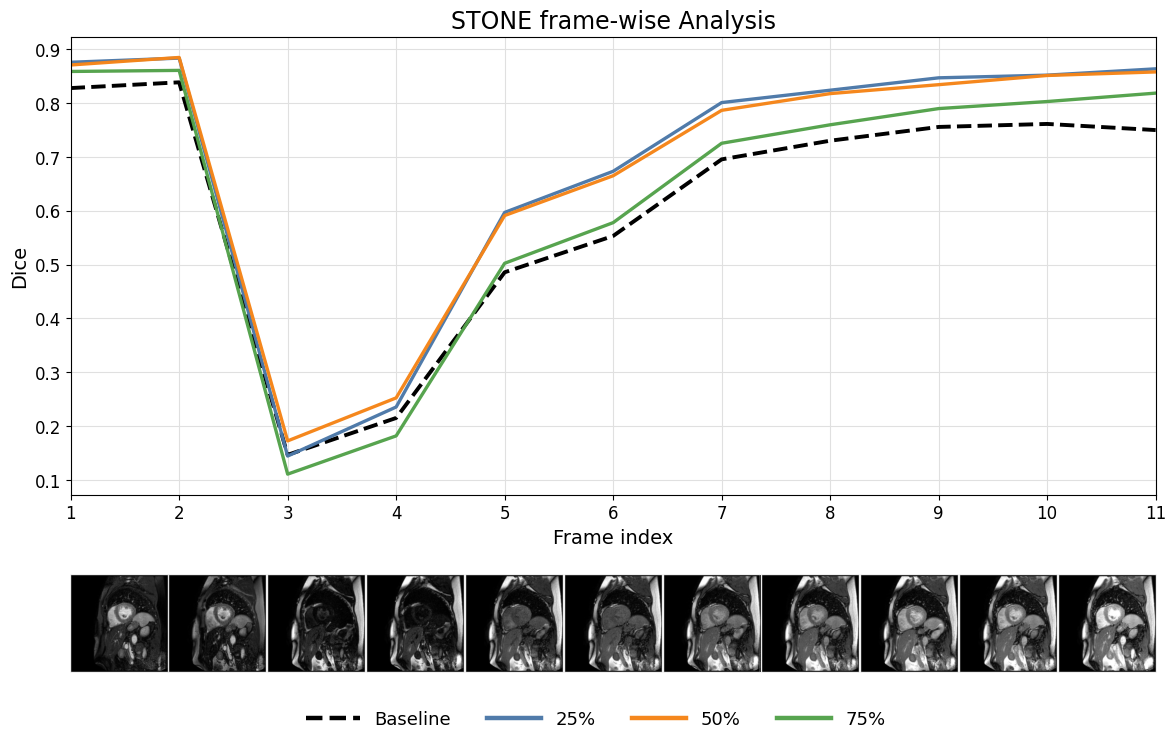

saved /mnt/hdd/ttoxopeus/basic_UNet/results/stone_slice_analysis/figures/dice_fg_vs_slice_position_selected_retrained.png


In [ ]:
def _pick_retrained_ratio_rows(summary_df: pd.DataFrame, targets=(0.25, 0.50, 0.75)) -> pd.DataFrame:
    retrained = summary_df[summary_df['mode'] == 'retrained'].copy()
    rows = []
    seen = set()
    for target in targets:
        if retrained.empty:
            continue
        row = retrained.iloc[(retrained['pruning_ratio'] - target).abs().argmin()]
        key = (row['run_name'], row['mode'])
        if key in seen:
            continue
        seen.add(key)
        rows.append(row)
    return pd.DataFrame(rows)


def _pick_representative_stone_case(metric_df: pd.DataFrame) -> dict:
    baseline_df = metric_df[metric_df['mode'] == 'baseline'].copy()
    case_summary = (
        baseline_df.groupby('case_id', as_index=False)
        .agg(mean_dice_fg=('dice_fg', 'mean'), num_slices=('slice_idx', 'size'))
    )
    case_summary = case_summary[case_summary['num_slices'] >= max(4, case_summary['num_slices'].median())].copy()
    median_dice = case_summary['mean_dice_fg'].median()
    case_summary['distance_to_median'] = (case_summary['mean_dice_fg'] - median_dice).abs()
    ranked = case_summary.sort_values(['distance_to_median', 'num_slices'], ascending=[True, False]).reset_index(drop=True)
    chosen = ranked.iloc[1] if len(ranked) > 1 else ranked.iloc[0]
    return next(pair for pair in STONE_PAIRS if pair['case_id'] == chosen['case_id'])


def _load_all_case_slices(pair: dict):
    img_vol = nib.load(str(pair['image_path'])).get_fdata()
    axis = int(STONE_CFG['slice_axis'])
    n_slices = int(img_vol.shape[axis])
    clip_bounds = tuple(np.percentile(img_vol, [1, 99]).tolist())
    selected = []
    for slice_idx in range(n_slices):
        img_slice = np.take(img_vol, slice_idx, axis=axis)
        img_tensor = preprocess_image_slice(img_slice, target_size=STONE_CFG['target_size'], clip_bounds=clip_bounds)
        selected.append({
            'slice_idx': slice_idx,
            'image': img_tensor.squeeze(0).cpu().numpy(),
        })
    return selected


def plot_slice_position_curves_selected(metric_df: pd.DataFrame, summary_df: pd.DataFrame, metric: str = 'dice_fg', title: str = ''):
    selected_retrained = _pick_retrained_ratio_rows(summary_df)
    keep_names = {'baseline'} | set(selected_retrained['run_name'].tolist())
    plot_df = metric_df[metric_df['run_name'].isin(keep_names)].copy()

    representative_case = _pick_representative_stone_case(plot_df)
    representative_slices = _load_all_case_slices(representative_case)
    n_slices = len(representative_slices)

    fig = plt.figure(figsize=(max(14, 0.55 * n_slices), 8.8))
    gs = fig.add_gridspec(nrows=2, ncols=n_slices, height_ratios=[3.8, 1.5], hspace=0.12, wspace=0.02)
    ax = fig.add_subplot(gs[0, :])
    slice_axes = [fig.add_subplot(gs[1, i]) for i in range(n_slices)]
    retrained_colors = ['#4C78A8', '#F58518', '#54A24B']

    baseline_sub = (
        plot_df[plot_df['mode'] == 'baseline']
        .groupby('slice_idx', as_index=False)[metric]
        .mean()
        .sort_values('slice_idx')
    )
    if not baseline_sub.empty:
        ax.plot(
            baseline_sub['slice_idx'] + 1,
            baseline_sub[metric],
            label='Baseline',
            linewidth=2.8,
            linestyle='--',
            color='black',
        )

    for color, (_, row) in zip(retrained_colors, selected_retrained.sort_values('pruning_ratio').iterrows()):
        sub = plot_df[(plot_df['run_name'] == row['run_name']) & (plot_df['mode'] == 'retrained')]
        sub = (
            sub.groupby('slice_idx', as_index=False)[metric]
            .mean()
            .sort_values('slice_idx')
        )
        ratio_pct = int(round(row['pruning_ratio'] * 100))
        ax.plot(
            sub['slice_idx'] + 1,
            sub[metric],
            label=f'{ratio_pct}%',
            linewidth=2.4,
            alpha=0.98,
            color=color,
        )

    label_fs = 14
    tick_fs = 12
    title_fs = 17

    ax.set_xlabel('Frame index', fontsize=label_fs)
    ax.set_ylabel('Dice', fontsize=label_fs)
    ax.set_title(title or 'STONE slice-wise Analysis', fontsize=title_fs)
    ax.set_xticks(range(1, n_slices + 1))
    ax.tick_params(axis='x', labelsize=tick_fs)
    ax.tick_params(axis='y', labelsize=tick_fs)
    ax.set_xlim(1, max(1, n_slices))
    ax.grid(True, which='major', axis='both', color='0.88', linewidth=0.8)
    ax.set_axisbelow(True)

    for thumb_ax, example in zip(slice_axes, representative_slices):
        thumb_ax.imshow(example['image'], cmap='gray', vmin=0.0, vmax=1.0)
        thumb_ax.set_xticks([])
        thumb_ax.set_yticks([])
        thumb_ax.set_aspect('equal')
        for spine in thumb_ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.35)
            spine.set_edgecolor('0.75')

    legend = fig.legend(
        frameon=False,
        fontsize=13,
        ncol=4,
        loc='lower center',
        bbox_to_anchor=(0.5, 0.075),
        handlelength=3.0,
    )
    for line in legend.get_lines():
        line.set_linewidth(3.2)

    fig.tight_layout(rect=(0, 0.09, 1, 1))
    out = FIG_DIR / f'{metric}_vs_slice_position_selected_retrained.png'
    fig.savefig(out, dpi=220, bbox_inches='tight')
    plt.show()
    print('saved', out)


plot_slice_position_curves_selected(
    slice_metrics_df,
    selected_runs_df,
    metric='dice_fg',
    title='STONE frame-wise Analysis'
)

## Plot 2: Class-wise slice-position trends for the baseline and the strongest retrained run


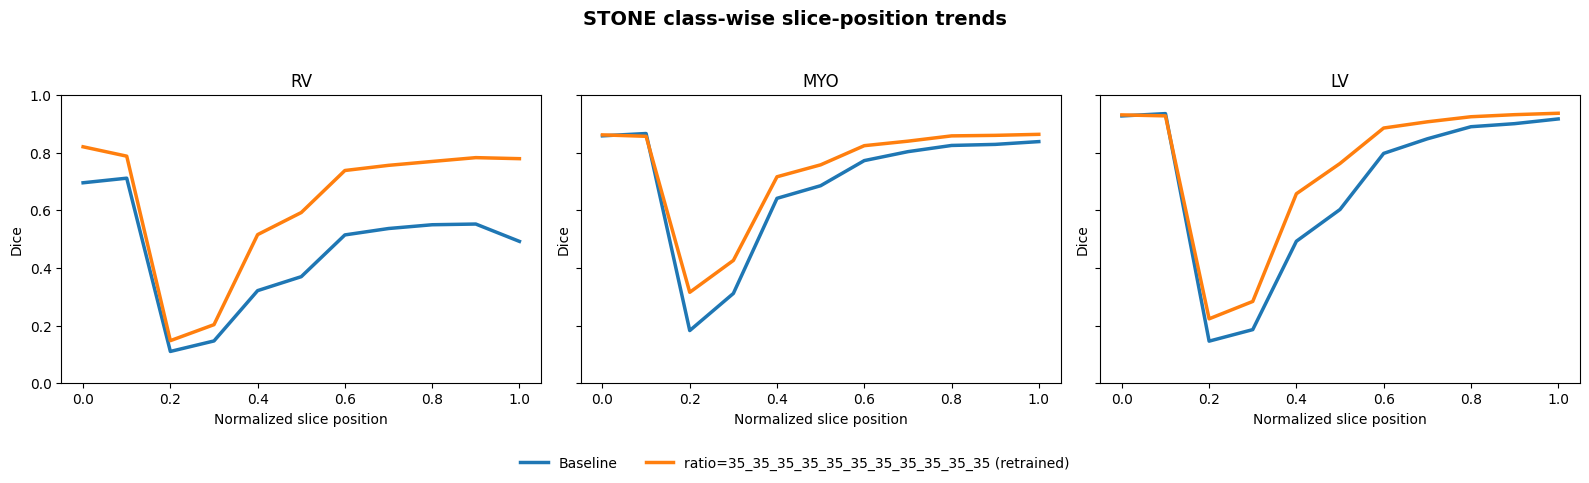

saved /mnt/hdd/ttoxopeus/basic_UNet/results/stone_slice_analysis/figures/classwise_slice_position.png


In [9]:
best_retrained_row = (
    run_summary_check[run_summary_check['mode'] == 'retrained']
    .sort_values('recomputed_mean_dice_fg', ascending=False)
    .iloc[0]
)
compare_names = {'baseline', best_retrained_row['run_name']}
class_plot_df = slice_metrics_df[slice_metrics_df['run_name'].isin(compare_names)].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)
metrics = [('dice_rv', 'RV'), ('dice_myo', 'MYO'), ('dice_lv', 'LV')]
for ax, (metric, label) in zip(axes, metrics):
    grouped = (
        class_plot_df.groupby(['display_name', 'mode', 'slice_pos'], as_index=False)[metric]
        .mean()
        .sort_values(['display_name', 'slice_pos'])
    )
    for (display_name, mode), sub in grouped.groupby(['display_name', 'mode']):
        line_label = f"{display_name} ({mode})" if mode != 'baseline' else 'Baseline'
        ax.plot(sub['slice_pos'], sub[metric], linewidth=2.5, label=line_label)
    ax.set_title(label)
    ax.set_xlabel('Normalized slice position')
    ax.set_ylabel('Dice')
    ax.set_ylim(0.0, 1.0)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, frameon=False)
fig.suptitle('STONE class-wise slice-position trends', fontsize=14, fontweight='bold')
fig.tight_layout(rect=(0, 0.08, 1, 0.95))
out = FIG_DIR / 'classwise_slice_position.png'
fig.savefig(out, dpi=220, bbox_inches='tight')
plt.show()
print('saved', out)


## Plot 3: Distribution by anatomical slice bin

The plot below bins slices into coarse regions along the stack and compares the foreground Dice distribution between models.


,display_name,mode,slice_bin,mean_fg_dice,median_fg_dice
0,Baseline,baseline,0-20%,0.604338,7.863716e-01
1,Baseline,baseline,20-40%,0.350367,3.028184e-01
2,Baseline,baseline,40-60%,0.624333,6.495751e-01
3,Baseline,baseline,60-80%,0.742892,8.036999e-01
4,Baseline,baseline,80-100%,0.755566,7.926160e-01
5,ratio=35_35_35_35_35_35_35_35_35_35_35,retrained,0-20%,0.653070,8.587401e-01
6,ratio=35_35_35_35_35_35_35_35_35_35_35,retrained,20-40%,0.467588,4.192402e-01
7,ratio=35_35_35_35_35_35_35_35_35_35_35,retrained,40-60%,0.760759,8.585706e-01
8,ratio=35_35_35_35_35_35_35_35_35_35_35,retrained,60-80%,0.843304,9.099547e-01
9,ratio=35_35_35_35_35_35_35_35_35_35_35,retrained,80-100%,0.859795,9.154724e-01


/media/ttoxopeus/tmp/ipykernel_3725793/765591021.py:14: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_bins = summary_bins.pivot_table(index='slice_bin', columns='display_name', values='mean_fg_dice')


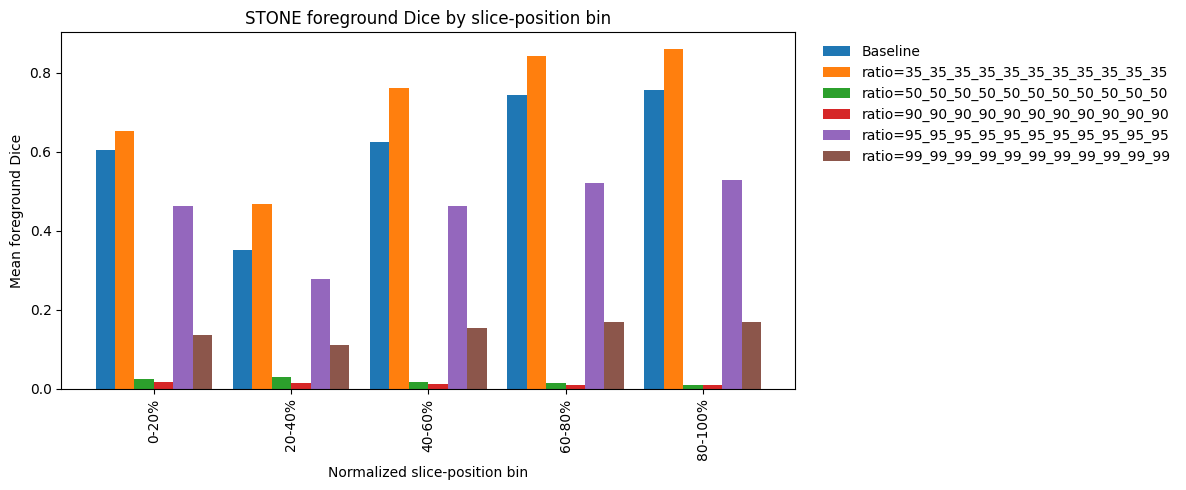

saved /mnt/hdd/ttoxopeus/basic_UNet/results/stone_slice_analysis/figures/dice_by_slice_bin.png


In [10]:
plot_df = slice_metrics_df.copy()
plot_df['slice_bin'] = pd.cut(
    plot_df['slice_pos'],
    bins=[-0.001, 0.2, 0.4, 0.6, 0.8, 1.001],
    labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%'],
)

summary_bins = (
    plot_df.groupby(['display_name', 'mode', 'slice_bin'], observed=True, as_index=False)
    .agg(mean_fg_dice=('dice_fg', 'mean'), median_fg_dice=('dice_fg', 'median'))
)
display(summary_bins)

pivot_bins = summary_bins.pivot_table(index='slice_bin', columns='display_name', values='mean_fg_dice')
pivot_bins.plot(kind='bar', figsize=(12, 5), width=0.85)
plt.ylabel('Mean foreground Dice')
plt.xlabel('Normalized slice-position bin')
plt.title('STONE foreground Dice by slice-position bin')
plt.legend(frameon=False, bbox_to_anchor=(1.02, 1.0), loc='upper left')
plt.tight_layout()
out = FIG_DIR / 'dice_by_slice_bin.png'
plt.savefig(out, dpi=220, bbox_inches='tight')
plt.show()
print('saved', out)


## Plot 4: Example case-level slice profiles

This final plot shows how slice-wise foreground Dice changes through the stack for one representative STONE case. The selected case is chosen as the median foreground-Dice case under the baseline model.


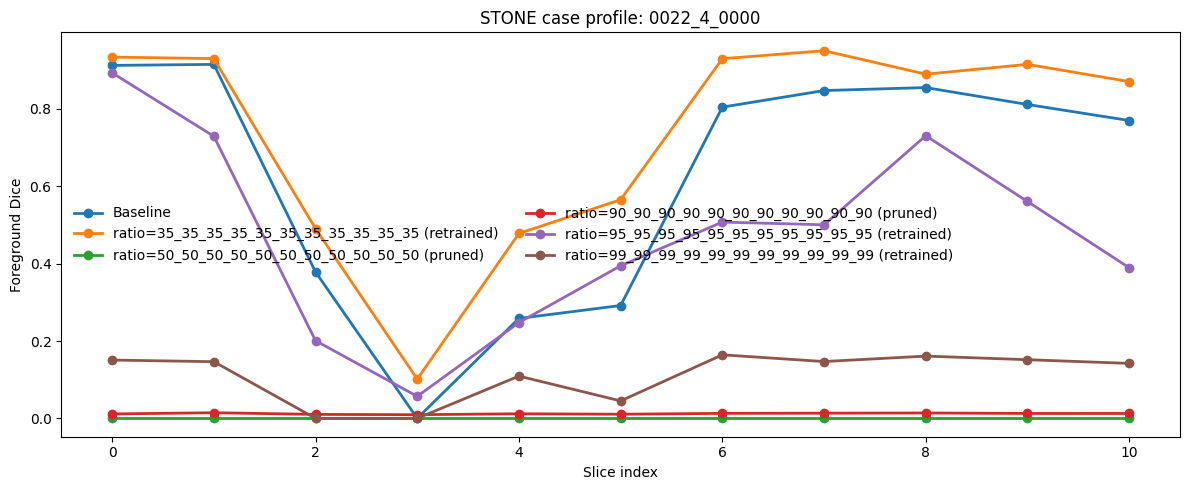

saved /mnt/hdd/ttoxopeus/basic_UNet/results/stone_slice_analysis/figures/case_profile_0022_4_0000.png


In [11]:
baseline_case_scores = (
    slice_metrics_df[slice_metrics_df['mode'] == 'baseline']
    .groupby('case_id', as_index=False)
    .agg(case_mean_fg_dice=('dice_fg', 'mean'))
    .sort_values('case_mean_fg_dice')
)
median_case = baseline_case_scores.iloc[len(baseline_case_scores) // 2]['case_id']
case_profile_df = slice_metrics_df[slice_metrics_df['case_id'] == median_case].copy()

plt.figure(figsize=(12, 5))
for (display_name, mode), sub in case_profile_df.groupby(['display_name', 'mode']):
    plt.plot(
        sub['slice_idx'],
        sub['dice_fg'],
        marker='o',
        linewidth=2.0,
        label=f"{display_name} ({mode})" if mode != 'baseline' else 'Baseline',
    )
plt.xlabel('Slice index')
plt.ylabel('Foreground Dice')
plt.title(f'STONE case profile: {median_case}')
plt.legend(frameon=False, ncol=2)
plt.tight_layout()
out = FIG_DIR / f'case_profile_{median_case}.png'
plt.savefig(out, dpi=220, bbox_inches='tight')
plt.show()
print('saved', out)


## Notes

- This notebook is aligned with the **uniform L1 STONE** experiment family used in `report_plots.ipynb`, but recomputes metrics at the **slice level**.
- The default dataset is **`Dataset100_STONE_small`** to stay consistent with the STONE pruning experiment configs.
- The `exp85_stone_l1` baseline metadata appears inconsistent, so the baseline checkpoint is supplied explicitly.
- Cached slice-level CSVs are saved under `results/stone_slice_analysis/cache/` to make reruns much faster.
